In [1]:
# صندوق بخشی پتروشیمی مفید fundkey = 17 issuerKey = 34741

query = """ SELECT 
        f.customerKey AS customerKey,
        AVG(f.quantity) AS quantity
    FROM 
        MofidDW.dbo.FactPortfolioLatest f
    WHERE 
        f.fromDateKey <= 14030619
        AND f.toDateKey <= 14030715
        and issuerKey = 34741
    GROUP BY 
        f.customerKey
    HAVING 
        AVG(f.quantity) > 0
         """

In [2]:
import sys

sys.path.append('/usr/local/lib/python3.10/dist-packages')
from ambdutils.functions import read_from_mofiddw


data = read_from_mofiddw(query)

/usr/local/lib/python3.10/dist-packages/ambdutils/functions.py:89: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, con)


In [3]:
data.shape

(4684, 2)

In [4]:
import pandas as pd 
agent_customer= pd.read_pickle('../agentcustomerkeys/agent_data.pkl')
agent_customer.shape

(834, 2)

In [5]:
# remove mofid agent from data 
indexes = data[data.customerKey.isin(agent_customer.customerkey.unique())].index
print(f"number of agent customer in ocatn: {len(indexes)}")
data.drop(indexes, inplace=True)

number of agent customer in ocatn: 277


In [7]:
data.shape

(4407, 2)

# مشتریان معمولی 

In [10]:
path = 'مشتریان عادی/task3891_control_detail.xlsx'
init_df = pd.read_excel(path)
print(init_df.is_sent.value_counts())
target_group_  = set(init_df[init_df.is_sent==1].customerKey.unique().tolist())
control_group_ = set(init_df[init_df.is_sent==0].customerKey.unique().tolist())


is_sent
1    664770
0     73364
Name: count, dtype: int64


In [11]:
target_group_data_normal =  data[(data.customerKey.isin(target_group_)) & (~data.customerKey.isin(control_group_))]
contol_group_data_normal =  data[(~data.customerKey.isin(target_group_)) & (data.customerKey.isin(control_group_))]
print(f"number of normal target group: {target_group_data_normal.shape[0]}")
print(f"number of normal control group: {contol_group_data_normal.shape[0]}")

number of normal target group: 2605
number of normal control group: 213


In [58]:
print(target_group_data_normal.quantity.sum())
print(contol_group_data_normal.quantity.sum())

12379154
615538


In [66]:
# target_group_data_normal = target_group_data_normal.merge(init_df[["customerKey", "سگمنت"]], on="customerKey").drop_duplicates()
# contol_group_data_normal = contol_group_data_normal.merge(init_df[["customerKey", "سگمنت"]], on="customerKey").drop_duplicates()
# target_group_data_normal["messeges"] =1 
# contol_group_data_normal["messeges"] = 0
# merged_data_norma = pd.concat([contol_group_data_normal,target_group_data_normal], axis=0)
grouped = merged_data_norma.groupby(["messeges", 'سگمنت'])

summary = grouped.agg(
    total_unique_customers=('customerKey', 'nunique'),
    total_quantity=('quantity', 'sum')
).reset_index()

overall_totals = summary[['total_unique_customers', 'total_quantity']].sum()
summary['customerKey_percent'] = (summary['total_unique_customers'] / overall_totals['total_unique_customers']) * 100
summary['quantity_percent'] = (summary['total_quantity'] / overall_totals['total_quantity']) * 100

summary

,messeges,سگمنت,total_unique_customers,total_quantity,customerKey_percent,quantity_percent
0,0,مشتریان رقبا,3,32400,0.106458,0.249333
1,0,پذیره نویسی ‌های قبلی,175,404719,6.210078,3.114495
2,0,پورتفو پتروشیمی,35,178419,1.242016,1.373014
3,1,مشتریان رقبا,18,210695,0.638751,1.621393
4,1,پذیره نویسی ‌های قبلی,2108,9513257,74.804826,73.208792
5,1,پورتفو پتروشیمی,479,2655202,16.997871,20.432974


In [22]:
from campaignutils.statistical import StatisticalTests as s


In [29]:
levene_t , levene_pvalue = s.levene_test(data1=target_group_data_normal, data2=contol_group_data_normal, feature='quantity')
print("levene test")
print(f"statistical t: {levene_t}")
print(f"p-value:       {levene_pvalue}")
if levene_pvalue > 0.05:
    print("varaince of these two sample are similar")

levene test
statistical t: 1.8141409421098271
p-value:       0.17812066342083693
varaince of these two sample are similar


In [16]:
# t-test
t, p_value = StatisticalTests.t_test(data1=target_group_data_normal, data2=contol_group_data_normal,\
                                     alternative="two-sided", equal_var=True, feature='quantity')
print(f"statistical t: {t}")
print(f"p-value:       {p_value}")

statistical t: 1.4102783583881913
p-value:       0.15856795066638565


In [20]:
t, p_value = StatisticalTests.t_test(data1=target_group_data_normal, data2=contol_group_data_normal,\
                                     alternative="greater", equal_var=True, feature='quantity')
print(f"statistical t: {t}")
print(f"p-value:       {p_value}")

statistical t: 1.4102783583881913
p-value:       0.07928397533319283


In [70]:
segments = merged_data_norma['سگمنت'].unique()

# Step 2: Initialize an empty results dictionary to store t-test results
ttest_results = {}

# Step 3: Loop through each segment and perform t-test
for segment in segments:
    # Filter data for the current segment
    segment_data = merged_data_norma[merged_data_norma['سگمنت'] == segment]

    # Separate the target and control groups within this segment
    target_group  = segment_data[segment_data['messeges'] == 1]['quantity'].values
    control_group = segment_data[segment_data['messeges'] == 0]['quantity'].values
    
    # Check if both groups have enough data points to perform t-test
    if len(target_group) > 1 and len(control_group) > 1:
        # Perform a two-sided t-test for each segment
        t_stat, p_value = StatisticalTests.t_test(target_group, control_group, alternative='greater')

        # Save the t-statistic and p-value for this segment
        ttest_results[segment] = {'t-statistic': t_stat, 'p-value': p_value}
    else:
        # If not enough data to perform a t-test, note this in the results.
        ttest_results[segment] = {'t-statistic': None, 'p-value': None, 'note': 'Not enough data points'}

# Step 4: Display t-test results for each segment
for segment, result in ttest_results.items():
    print(f"Segment: {segment}")
    if result['t-statistic'] is not None:
        print(f"  T-statistic: {result['t-statistic']}")
        print(f"  P-value: {result['p-value']}")
        if result['p-value'] < 0.05:
            print("  -> Statistically significant difference between target and control groups!")
        else:
            print("  -> No statistically significant difference.")
    else:
        print(f"  -> {result.get('note', 'Error occurred')}")
    print("-" * 50)

Segment: پذیره نویسی ‌های قبلی
  T-statistic: 1.4695352921206228
  P-value: 0.0709127808628964
  -> No statistically significant difference.
--------------------------------------------------
Segment: مشتریان رقبا
  T-statistic: 0.06460333670145184
  P-value: 0.47458235185493547
  -> No statistically significant difference.
--------------------------------------------------
Segment: پورتفو پتروشیمی
  T-statistic: 0.16015322615211622
  P-value: 0.4364117687055401
  -> No statistically significant difference.
--------------------------------------------------


# مشتریان ثروتمند

In [123]:
df_rich  = pd.read_excel('تحلیل مشتریان ثروتمند/وضعیت تماس.xlsx')
print(df_rich["نتیجه تماس"].value_counts())
target_rich_customerkeys = df_rich[df_rich["نتیجه تماس"] =="برقرار شده"].customerKey.unique().tolist()

نتیجه تماس
برقرار شده     7255
برقرار نشده    3630
Name: count, dtype: int64


In [124]:
df1= pd.read_csv('مشتریان ثروتمند/output/control_bakhshi_customer.csv')
df2= pd.read_csv('مشتریان ثروتمند/output/control_hnw_customer.csv')
df3= pd.read_csv('مشتریان ثروتمند/output/control_loyal_customer.csv')
df4= pd.read_csv('مشتریان ثروتمند/output/control_petroleum_customer.csv')
df1["سگمنت کلی"] =  'مشتریان بخشی'
df2["سگمنت کلی"] =  'HNW'
df3["سگمنت کلی"] =  'مشتریان وفادار'
df4["سگمنت کلی"] =  'دارای سهام شیمایی'
control_df_rich  = pd.concat([df1, df2, df3, df4], axis=0)
control_rich_customerkeys = control_df_rich.customerkey.unique()

In [125]:
target_group_data_rich =  data[(data.customerKey.isin(target_rich_customerkeys)) & (~data.customerKey.isin(control_rich_customerkeys))]
contol_group_data_rich =  data[(~data.customerKey.isin(target_rich_customerkeys)) & (data.customerKey.isin(control_rich_customerkeys))]
print(f"number of normal target group: {target_group_data_rich.shape[0]}")
print(f"number of normal control group: {contol_group_data_rich.shape[0]}")

number of normal target group: 213
number of normal control group: 51


In [126]:
print(target_group_data_rich.quantity.sum())
print(contol_group_data_rich.quantity.sum())

9876702
1143100


In [127]:
target_group_data_rich = target_group_data_rich.merge(df_rich[["customerKey", 'سگمنت کلی']], on="customerKey").drop_duplicates()
contol_group_data_rich = contol_group_data_rich.merge(control_df_rich[["customerkey", 'سگمنت کلی']], left_on="customerKey",right_on="customerkey").drop_duplicates()
target_group_data_rich["messeges"] =1 
contol_group_data_rich["messeges"] = 0
merged_data_rich = pd.concat([contol_group_data_rich, target_group_data_rich], axis=0)
grouped = merged_data_rich.groupby(["messeges", 'سگمنت کلی'])

summary = grouped.agg(
    total_unique_customers=('customerKey', 'nunique'),
    total_quantity=('quantity', 'sum')
).reset_index()

overall_totals = summary[['total_unique_customers', 'total_quantity']].sum()
summary['customerKey_percent'] = (summary['total_unique_customers'] / overall_totals['total_unique_customers']) * 100
summary['quantity_percent'] = (summary['total_quantity'] / overall_totals['total_quantity']) * 100

summary

,messeges,سگمنت کلی,total_unique_customers,total_quantity,customerKey_percent,quantity_percent
0,0,دارای سهام شیمایی,7,198945,2.631579,1.803459
1,0,مشتریان بخشی,22,851249,8.270677,7.716668
2,0,مشتریان وفادار,24,104406,9.022556,0.946452
3,1,HNW,2,70000,0.751880,0.634558
4,1,دارای سهام شیمایی,53,2547443,19.924812,23.092859
5,1,شاغلین صنعت,15,293601,5.639098,2.661526
6,1,قبلا سهام شیمایی داشته,13,755234,4.887218,6.846282
7,1,مشتریان بخشی,22,5114790,8.270677,46.366150
8,1,مشتریان وفادار,108,1095634,40.601504,9.932046


In [96]:
levene_t , levene_pvalue = s.levene_test(data1=target_group_data_rich, data2=contol_group_data_rich, feature='quantity')
print("levene test")
print(f"statistical t: {levene_t}")
print(f"p-value:       {levene_pvalue}")
if levene_pvalue > 0.05:
    print("varaince of these two sample are similar")

levene test
statistical t: 0.4742435284494326
p-value:       0.4916461205951802
varaince of these two sample are similar


In [92]:
ks_t , ks_pvalue = s.ks2samp_test(data1=target_group_data_rich, data2=contol_group_data_rich, feature='quantity')
print("ks test")
print(f"statistical t: {ks_t}")
print(f"p-value:       {ks_pvalue}")
if ks_pvalue > 0.05:
    print("these two sample are similar")

ks test
statistical t: 0.12374878200017717
p-value:       0.49275577049656016
these two sample are similar


In [94]:
# t-test
t, p_value = StatisticalTests.t_test(data1=target_group_data_rich, data2=contol_group_data_rich,\
                                     alternative="two-sided", equal_var=True, feature='quantity')
print(f"statistical t: {t}")
print(f"p-value:       {p_value}")

statistical t: 0.7072208157944762
p-value:       0.4800530650174647


In [95]:
t, p_value = StatisticalTests.t_test(data1=target_group_data_rich, data2=contol_group_data_rich,\
                                     alternative="greater", equal_var=True, feature='quantity')
print(f"statistical t: {t}")
print(f"p-value:       {p_value}")

statistical t: 0.7072208157944762
p-value:       0.24002653250873235


In [97]:
segments = merged_data_rich['سگمنت کلی'].unique()

# Step 2: Initialize an empty results dictionary to store t-test results
ttest_results = {}

# Step 3: Loop through each segment and perform t-test
for segment in segments:
    # Filter data for the current segment
    segment_data = merged_data_rich[merged_data_rich['سگمنت کلی'] == segment]

    # Separate the target and control groups within this segment
    target_group  = segment_data[segment_data['messeges'] == 1]['quantity'].values
    control_group = segment_data[segment_data['messeges'] == 0]['quantity'].values
    
    # Check if both groups have enough data points to perform t-test
    if len(target_group) > 1 and len(control_group) > 1:
        # Perform a two-sided t-test for each segment
        t_stat, p_value = StatisticalTests.t_test(target_group, control_group, alternative='greater')

        # Save the t-statistic and p-value for this segment
        ttest_results[segment] = {'t-statistic': t_stat, 'p-value': p_value}
    else:
        # If not enough data to perform a t-test, note this in the results.
        ttest_results[segment] = {'t-statistic': None, 'p-value': None, 'note': 'Not enough data points'}

# Step 4: Display t-test results for each segment
for segment, result in ttest_results.items():
    print(f"Segment: {segment}")
    if result['t-statistic'] is not None:
        print(f"  T-statistic: {result['t-statistic']}")
        print(f"  P-value: {result['p-value']}")
        if result['p-value'] < 0.05:
            print("  -> Statistically significant difference between target and control groups!")
        else:
            print("  -> No statistically significant difference.")
    else:
        print(f"  -> {result.get('note', 'Error occurred')}")
    print("-" * 50)

Segment: مشتریان وفادار
  T-statistic: 2.2071604604189305
  P-value: 0.014528815029318621
  -> Statistically significant difference between target and control groups!
--------------------------------------------------
Segment: دارای سهام شیمایی
  T-statistic: 0.7506189525996462
  P-value: 0.22795827093669302
  -> No statistically significant difference.
--------------------------------------------------
Segment: مشتریان بخشی
  T-statistic: 1.1917374526776991
  P-value: 0.12002745372756547
  -> No statistically significant difference.
--------------------------------------------------
Segment: شاغلین صنعت
  -> Not enough data points
--------------------------------------------------
Segment: قبلا سهام شیمایی داشته
  -> Not enough data points
--------------------------------------------------
Segment: HNW
  -> Not enough data points
--------------------------------------------------


In [53]:
from campaignutils.visualize import plot_numeric_distribution

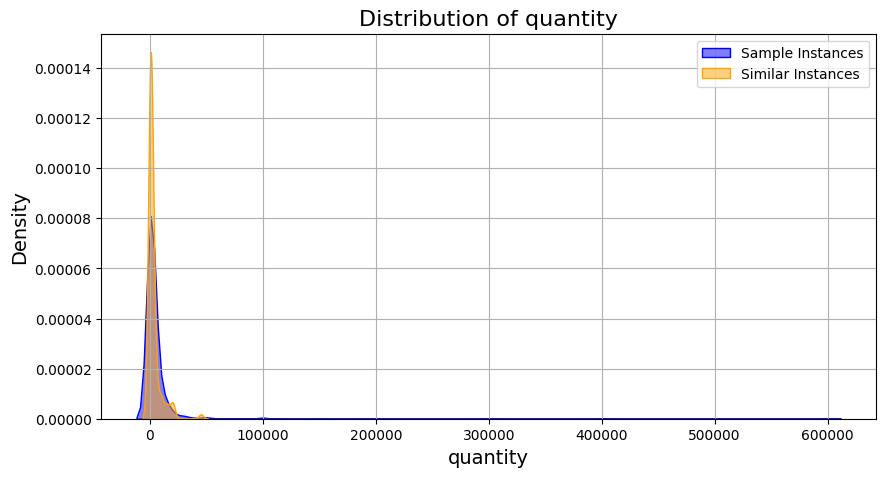

In [55]:
plot_numeric_distribution(target_group_data_normal,contol_group_data_normal, feature='quantity' )

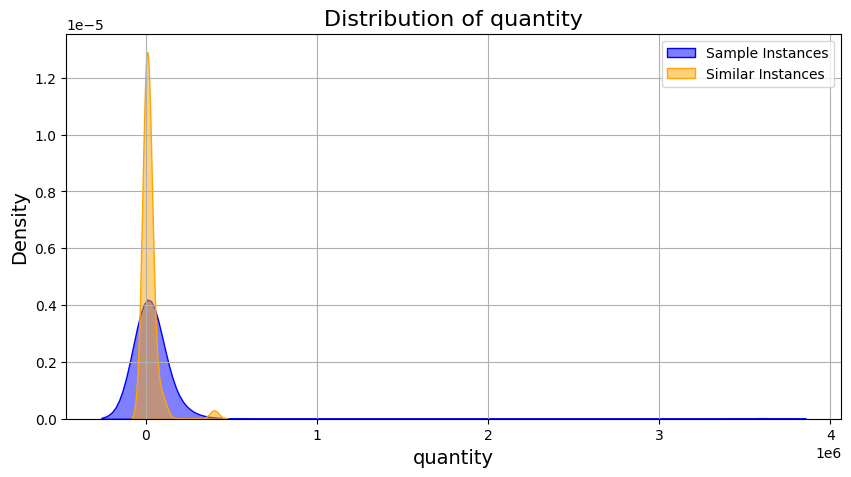

In [54]:
plot_numeric_distribution(target_group_data_rich,contol_group_data_rich, feature='quantity' )

### تعدا باقی مانده

In [167]:
reamin_data = data.loc[
~(data.customerKey.isin(merged_data_rich.customerKey.unique()))\
& ~(data.customerKey.isin(merged_data_norma.customerKey.unique()))]

In [170]:
reamin_data.shape

(1373, 2)

In [176]:
print(reamin_data[reamin_data.customerKey != 285150].quantity.sum())

11284155
